# M2 — Is the frozen PFN surrogate trustworthy? (risk gate for §2.12)

Implements `docs/ROADMAP.md` §3 M2's exit criterion: standalone BO quality
with the frozen PFN as the surrogate (posterior mean/EI computed off its
predictive distribution), compared against a classical baseline on the
*same* tasks — a plain BoTorch GP + EI, per this project's own note
(the roadmap originally named PFNs4BO's HEBO+ model; a from-scratch
comparison against a code-identical-family GP+EI baseline is more useful
here and is what `models/baselines/gp_acquisition.py` already builds).

**Why this check exists (§2.12):** everything from M4 onward reads the PFN
as a stand-in for a real posterior. PFNs4BO's own strongest model is
trained on a *different* prior (HEBO+ GP) than this project's own
environment (the BNN prior, §1.6 — required, since only a callable
ground-truth environment supports the branch-and-replay data generation the
whole design depends on). So the prior that makes the best *environment*
might not make the best *surrogate* — this notebook is the check for
whether the BNN-prior-trained PFN is good enough to build a policy on top
of, or whether it's already a ceiling before any Q-head training starts.

**Checkpoint used:** `models/pfn_variable_xdim_smoke.pt`. Its experiment
config's own comment claims "Not a serious training run... 500 steps" —
**that comment is stale**: the checkpoint's own logged `history` (read
below) shows it actually trained for far longer. Trust the checkpoint's
logged history over the config comment when the two disagree.

**Method — a *shared task set*, per the exit criterion's wording:** each
policy (random, GP+EI, PFN-surrogate+EI) is rolled out against a
`BNNPrior` batch constructed with the *same seed*, so all three see
literally the same set of true functions (and the same initial `n_init`
context points) — differences in outcome are attributable to the policy,
not to which functions happened to be sampled. (Noise realizations along
each trajectory differ trivially anyway, since the policies query different
points — that's fine and unavoidable, unlike the function draws themselves.)

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import torch

from anytimeacquisition.metrics.inc_auc import log_incumbent_auc
from anytimeacquisition.metrics.rollout import random_policy, rollout_episode
from anytimeacquisition.models.baselines.gp_acquisition import gp_acquisition_policy
from anytimeacquisition.models.surrogates.pfn_surrogate import PFNSurrogate, pfn_surrogate_ei_policy
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.reward.tail_quantile_reward import build_ecdf, g_reward_minimize, percentile
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

pfn, bar_dist, ckpt = load_pfn_checkpoint(CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt")
surrogate = PFNSurrogate(pfn, bar_dist, use_bf16=False)  # bf16 autocast on CPU: correct but no speedup here
print(f"checkpoint config: {ckpt['config']}")
print(f"checkpoint actually trained for {max(ckpt['history']['step'])} steps "
      f"({len(ckpt['history']['step'])} logged points) -- ignore the experiment config's stale comment")

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


checkpoint config: {'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}
checkpoint actually trained for 29999 steps (301 logged points) -- ignore the experiment config's stale comment


## Run the shared-task comparison

Per-environment normalization, before the rollouts — **why**: `BNNPrior.evaluate()`
bounds every draw's output to `[0,1]`, but that calibration is fit once,
*pooled* across ~50 architecture draws (`BNNPrior._fit_ecdf`) — not
per-instance. Individual draws still differ a lot in their *achievable
range* inside `[0,1]`: some architectures are "easy" (span nearly all of
it), others are "flat"/hard (compressed into a narrow band). Averaging raw
incumbent values across environments lets the easy/wide-range ones dominate
the mean and hides whether the policy is doing well *relative to what each
task actually offers*.

**Standard BO practice for exactly this** — aggregating across heterogeneous
benchmark instances — is to report *normalized regret* / *percentile-of-domain*
per task, not raw values: `(f - f_min)/(f_max - f_min)` when the optimum is
known, or, when it isn't but dense evaluation is available (true here —
privileged/ground-truth access), the empirical-CDF percentile against a
per-instance reference sample. That's exactly `docs/ROADMAP.md` §M1's own
`build_ecdf`/`percentile` — reused here rather than inventing a separate
normalization.

`matching_reference` reconstructs each `x_dim`'s exact environments (same
seed -> same architectures, verified against what `rollout_episode`'s own
internal `reset()` draws) purely to build this per-instance reference —
it does not affect the rollouts themselves.

In [2]:
BATCH_SIZE = 100  # independent environments (BNN function draws) per x_dim, shared across all 3 policies
N_INIT, N_STEPS = 5, 30
POLICY_SEED = 1  # candidate-proposal randomness (GP restarts, PFN's Sobol pool) -- independent of the task seed
REFERENCE_N = 100_000  # Sobol reference size per environment, matching M1's build_ecdf default

POLICIES = {
    "random": lambda: random_policy,
    "gp_ei": lambda: partial(gp_acquisition_policy, acquisition="EI", num_restarts=5, raw_samples=64),
    "pfn_surrogate_ei": lambda: partial(pfn_surrogate_ei_policy, surrogate=surrogate, n_candidates=256, seed=POLICY_SEED),
}


def matching_reference(x_dim: int, task_seed: int):
    """Same seed/batch/x_dim as run_shared_task_comparison below, plus one
    extra explicit reset() -- reproduces the exact environments
    rollout_episode's own internal reset() draws (verified: construct + its
    own __init__ reset, then rollout_episode's reset() is architecture-draw
    #2 relative to the seed; an independently constructed prior + one more
    explicit .reset() lands on that same #2 draw)."""
    prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=x_dim, seed=task_seed)
    prior.reset()
    return build_ecdf(prior, n_samples=REFERENCE_N, seed=1)


def normalized_score(y_context: torch.Tensor, y_sorted: torch.Tensor) -> torch.Tensor:
    """Per-instance-normalized incumbent trajectory, in [0,1] -- 1.0 means
    the incumbent has already beaten virtually the entire per-instance
    reference sample (this project minimizes, so "beaten" = smaller), 0.0
    means it's at the very worst end. Directly comparable across
    environments with different intrinsic scales, unlike raw y."""
    incumbent = torch.cummin(y_context, dim=1).values  # [B, T]
    u = percentile(y_sorted, incumbent)  # [B, T], fraction of the reference AT OR BELOW the incumbent
    return 1.0 - u


def g_score(y_context: torch.Tensor, y_sorted: torch.Tensor) -> torch.Tensor:
    """Same per-instance normalization as normalized_score, but through
    the M1 g-reward's log-scale tail-quantile transform (g_reward_minimize)
    instead of a linear percentile. normalized_score clusters strong
    policies near 1.0 on a [0,1] axis, which compresses exactly the
    differences that matter once everyone's "pretty good"; g-space
    stretches that region out (moving from the 90th to 99th percentile
    counts the same as 99th to 99.9th) -- and it's not just a plotting
    trick, it's literally the objective M4+ trains against."""
    incumbent = torch.cummin(y_context, dim=1).values  # [B, T]
    return g_reward_minimize(y_sorted, incumbent)


def run_shared_task_comparison(x_dim: int, task_seed: int = 0):
    y_sorted = matching_reference(x_dim, task_seed)
    rollouts = {}
    for name, make_policy in POLICIES.items():
        torch.manual_seed(task_seed)
        prior = BNNPrior(batch_size=BATCH_SIZE, x_dim=x_dim, seed=task_seed)  # same seed -> same functions
        rollouts[name] = rollout_episode(prior, n_init=N_INIT, n_steps=N_STEPS, policy_fn=make_policy())
    return rollouts, y_sorted


results = {}
for x_dim in (1, 2, 6):
    rollouts, y_sorted = run_shared_task_comparison(x_dim)
    aucs = {name: log_incumbent_auc(r["y_context"]) for name, r in rollouts.items()}
    norm_scores = {name: normalized_score(r["y_context"], y_sorted) for name, r in rollouts.items()}
    g_scores = {name: g_score(r["y_context"], y_sorted) for name, r in rollouts.items()}
    results[x_dim] = {"rollouts": rollouts, "aucs": aucs, "norm_scores": norm_scores, "g_scores": g_scores}

    print(f"--- x_dim={x_dim} (log-incumbent AUC: lower is better) ---")
    for name, auc in aucs.items():
        se = auc.std().item() / (BATCH_SIZE ** 0.5)
        print(f"  {name:20s} mean {auc.mean().item():8.4f}  +/- {se:.4f} (se, n={BATCH_SIZE})")
    gap = aucs["pfn_surrogate_ei"].mean().item() - aucs["gp_ei"].mean().item()
    print(f"  gap (pfn - gp, positive = GP still better): {gap:+.4f}")

    print(f"--- x_dim={x_dim} (normalized score, mean over steps AND envs: higher is better, in [0,1]) ---")
    for name, ns in norm_scores.items():
        mean_over_steps = ns.mean(dim=1)  # [B] -- anytime average per environment
        se = mean_over_steps.std().item() / (BATCH_SIZE ** 0.5)
        print(f"  {name:20s} mean {mean_over_steps.mean().item():.4f}  +/- {se:.4f} (se, n={BATCH_SIZE})")
    norm_gap = norm_scores["pfn_surrogate_ei"].mean(dim=1).mean().item() - norm_scores["gp_ei"].mean(dim=1).mean().item()
    print(f"  gap (pfn - gp, positive = PFN better here): {norm_gap:+.4f}")

    print(f"--- x_dim={x_dim} (g-reward score, mean over steps AND envs: higher is better, in [0,1], log-scale tail) ---")
    for name, gs in g_scores.items():
        mean_over_steps = gs.mean(dim=1)
        se = mean_over_steps.std().item() / (BATCH_SIZE ** 0.5)
        print(f"  {name:20s} mean {mean_over_steps.mean().item():.4f}  +/- {se:.4f} (se, n={BATCH_SIZE})")
    g_gap = g_scores["pfn_surrogate_ei"].mean(dim=1).mean().item() - g_scores["gp_ei"].mean(dim=1).mean().item()
    print(f"  gap (pfn - gp, positive = PFN better here): {g_gap:+.4f}")
    print()

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


...

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


--- x_dim=2 (log-incumbent AUC: lower is better) ---
  random               mean -53.8670  +/- 3.2087 (se, n=100)
  gp_ei                mean -58.6002  +/- 3.7430 (se, n=100)
  pfn_surrogate_ei     mean -56.9873  +/- 3.4043 (se, n=100)
  gap (pfn - gp, positive = GP still better): +1.6130
--- x_dim=2 (normalized score, mean over steps AND envs: higher is better, in [0,1]) ---
  random               mean 0.9100  +/- 0.0058 (se, n=100)
  gp_ei                mean 0.9357  +/- 0.0050 (se, n=100)
  pfn_surrogate_ei     mean 0.9312  +/- 0.0058 (se, n=100)
  gap (pfn - gp, positive = PFN better here): -0.0045
--- x_dim=2 (g-reward score, mean over steps AND envs: higher is better, in [0,1], log-scale tail) ---
  random               mean 0.4635  +/- 0.0266 (se, n=100)
  gp_ei                mean 0.6950  +/- 0.0211 (se, n=100)
  pfn_surrogate_ei     mean 0.6246  +/- 0.0234 (se, n=100)
  gap (pfn - gp, positive = PFN better here): -0.0704



/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/botorch/optim/optimize.py:789: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


--- x_dim=6 (log-incumbent AUC: lower is better) ---
  random               mean -75.2080  +/- 4.8347 (se, n=100)
  gp_ei                mean -81.5743  +/- 4.8674 (se, n=100)
  pfn_surrogate_ei     mean -75.3711  +/- 4.6291 (se, n=100)
  gap (pfn - gp, positive = GP still better): +6.2032
--- x_dim=6 (normalized score, mean over steps AND envs: higher is better, in [0,1]) ---
  random               mean 0.9075  +/- 0.0052 (se, n=100)
  gp_ei                mean 0.9286  +/- 0.0049 (se, n=100)
  pfn_surrogate_ei     mean 0.9146  +/- 0.0054 (se, n=100)
  gap (pfn - gp, positive = PFN better here): -0.0140
--- x_dim=6 (g-reward score, mean over steps AND envs: higher is better, in [0,1], log-scale tail) ---
  random               mean 0.3568  +/- 0.0105 (se, n=100)
  gp_ei                mean 0.5156  +/- 0.0187 (se, n=100)
  pfn_surrogate_ei     mean 0.4059  +/- 0.0160 (se, n=100)
  gap (pfn - gp, positive = PFN better here): -0.1097



## Incumbent trajectories — g-reward space, individual + mean

Every one of the `BATCH_SIZE` shared environments' own incumbent curve, in
**g-reward space** (thin lines) plus the mean across them (bold). Plotting
`normalized_score` directly (linear percentile, in `[0,1]`) squashes every
strong policy up near `1.0`, which compresses exactly the differences that
matter once everyone's already "pretty good" — the region this whole
comparison actually lives in. `g_reward_minimize` is the fix, and it isn't
just a plotting trick: it's `docs/ROADMAP.md` §M1's own log-scale
tail-quantile transform (moving from the 90th to 99th percentile counts the
same as 99th to 99.9th, clipped at 4 decades) — the *actual* metric M4+
trains against, so comparing policies in this space is more meaningful,
not just prettier.

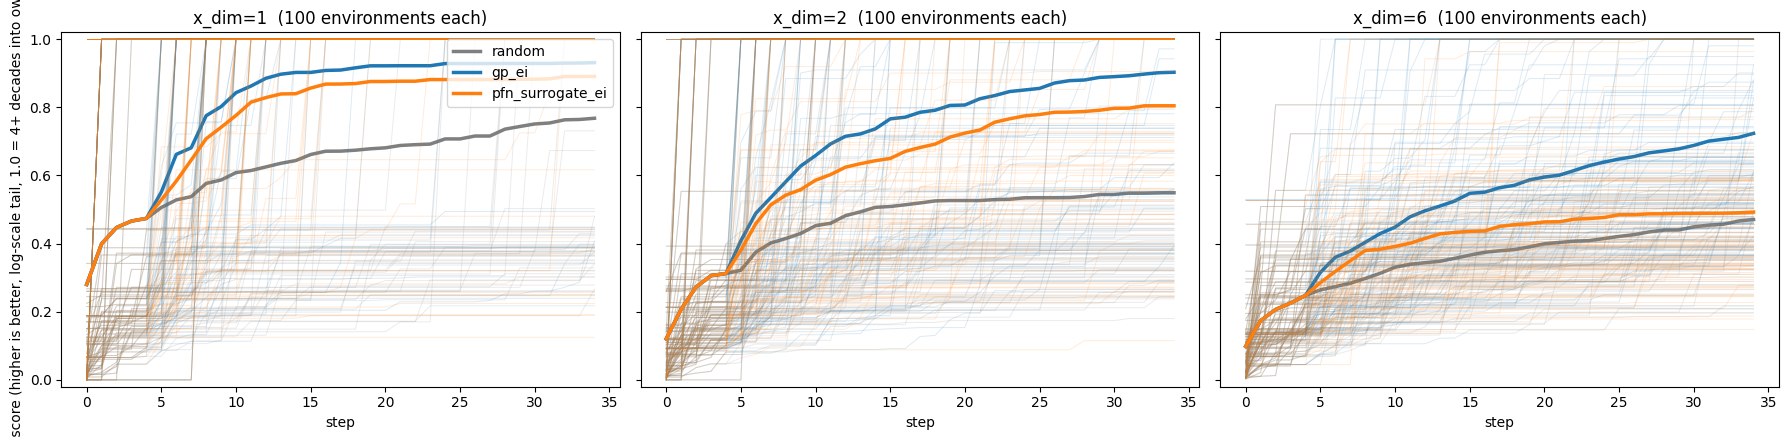

In [3]:
POLICY_COLORS = {"random": "tab:gray", "gp_ei": "tab:blue", "pfn_surrogate_ei": "tab:orange"}
DIMS = (1, 2, 6)

fig, axes = plt.subplots(1, len(DIMS), figsize=(6 * len(DIMS), 4.5), sharey=True)
for ax, x_dim in zip(axes, DIMS):
    for name, gs in results[x_dim]["g_scores"].items():
        color = POLICY_COLORS[name]
        for row in gs:
            ax.plot(row, color=color, alpha=0.15, linewidth=0.7)
        ax.plot(gs.mean(dim=0), color=color, linewidth=2.5, label=name)
    ax.set_title(f"x_dim={x_dim}  ({BATCH_SIZE} environments each)")
    ax.set_xlabel("step")
    ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("g-reward score (higher is better, log-scale tail, 1.0 = 4+ decades into own optimum)")
axes[0].legend()
plt.tight_layout()
plt.show()

## Cost curve: PFN forward time vs. context size `t` and candidate pool `C`

Second half of M2's exit criterion — confirms the `O(t(t+C))` attention
term and `O(C)` MLP term (§2.10), and gives a concrete number to pick `C`
from for later milestones' decision-time candidate pools.

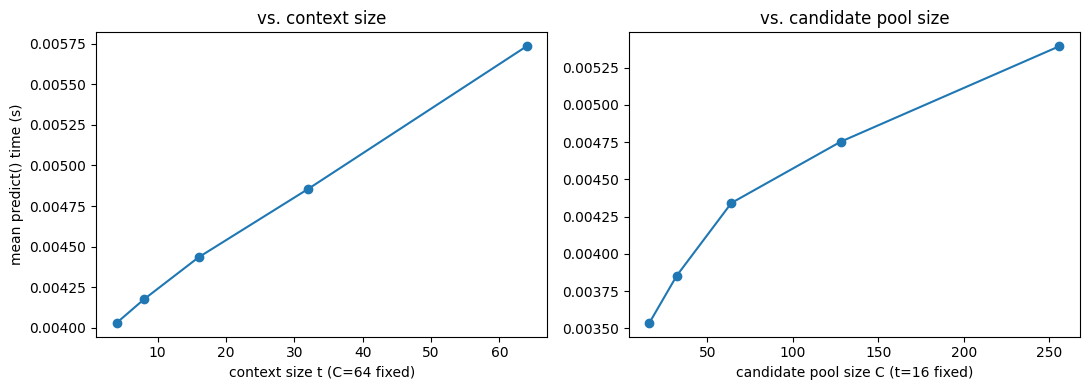

t=  4  C=64   predict() time: 4.03 ms
t=  8  C=64   predict() time: 4.17 ms
t= 16  C=64   predict() time: 4.43 ms
t= 32  C=64   predict() time: 4.85 ms
t= 64  C=64   predict() time: 5.74 ms
t=16  C=  16  predict() time: 3.54 ms
t=16  C=  32  predict() time: 3.85 ms
t=16  C=  64  predict() time: 4.34 ms
t=16  C= 128  predict() time: 4.75 ms
t=16  C= 256  predict() time: 5.39 ms


In [4]:
import time

def time_predict(t, C, n_repeats=5):
    prior = BNNPrior(batch_size=8, x_dim=2, seed=0)
    x_context, y_context, _, _ = prior.sample_episode(n_train=t, n_test=0)
    candidates = torch.rand(8, C, 2)
    surrogate.predict(x_context, y_context, candidates)  # warm-up (lazy imports, etc.)
    start = time.perf_counter()
    for _ in range(n_repeats):
        surrogate.predict(x_context, y_context, candidates)
    return (time.perf_counter() - start) / n_repeats


t_values = [4, 8, 16, 32, 64]
C_values = [16, 32, 64, 128, 256]

time_vs_t = [time_predict(t=t, C=64) for t in t_values]
time_vs_C = [time_predict(t=16, C=C) for C in C_values]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_values, time_vs_t, marker="o")
axes[0].set_xlabel("context size t (C=64 fixed)")
axes[0].set_ylabel("mean predict() time (s)")
axes[0].set_title("vs. context size")
axes[1].plot(C_values, time_vs_C, marker="o")
axes[1].set_xlabel("candidate pool size C (t=16 fixed)")
axes[1].set_title("vs. candidate pool size")
plt.tight_layout()
plt.show()

for t, dt in zip(t_values, time_vs_t):
    print(f"t={t:3d}  C=64   predict() time: {dt*1000:.2f} ms")
for C, dt in zip(C_values, time_vs_C):
    print(f"t=16  C={C:4d}  predict() time: {dt*1000:.2f} ms")

## Summary

Recorded in `docs/ROADMAP.md` §M2 — see the exit-criterion checklist there
for the actual numbers this run produced (they're printed above, not
hand-copied into this cell, so a rerun on a different/better-trained
checkpoint stays the source of truth).

**Three gap numbers, not all pointing the same way:** raw log-incumbent AUC
can be dominated by a few wide-range environments (the problem the
normalization section above exists to fix); normalized-score and g-score
are both per-instance-normalized versions of the same underlying quantity,
just linear vs. log-scale — trust their *direction* over raw AUC's, and
trust g-score's magnitude over normalized-score's once policies are
clustered near the top of `[0,1]` (see the plot's own reasoning above).

**Why `x_dim=6` is in the sweep:** random search is a famously strong
baseline at low dimensions (1-D/2-D) — a handful of random points already
covers the space densely, leaving little room for a smarter policy to add
value. That gap should widen in random's *disfavor* as dimensionality
grows, since its coverage degrades faster than an informed search's. Cuts
both ways, though: `callbacks/dim_validation.py` exists because the PFN's
*own* predictive quality is also expected to degrade at higher dimensions,
so `x_dim=6` (this checkpoint's trained ceiling) is a genuine test, not a
setup rigged to favor either baseline.